**Import Data Set**


In [ ]:
import pandas as pd
data=pd.read_excel("/content/Copy of Retail_Customer_Segmentation2.xlsx")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Month,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,December,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,December,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,December,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,December,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,December,3.39,17850.0,United Kingdom


**1. Who are our customers?**

Number of customers per country:
Country
United Kingdom          3950
Germany                   95
France                    87
Spain                     31
Belgium                   25
Switzerland               21
Portugal                  19
Italy                     15
Finland                   12
Austria                   11
Norway                    10
Channel Islands            9
Netherlands                9
Australia                  9
Denmark                    9
Cyprus                     8
Japan                      8
Sweden                     8
Poland                     6
Unspecified                4
Canada                     4
USA                        4
Greece                     4
Israel                     4
EIRE                       3
Bahrain                    2
Malta                      2
United Arab Emirates       2
Brazil                     1
Czech Republic             1
Saudi Arabia               1
Lebanon                    1
Iceland                    1
Eu

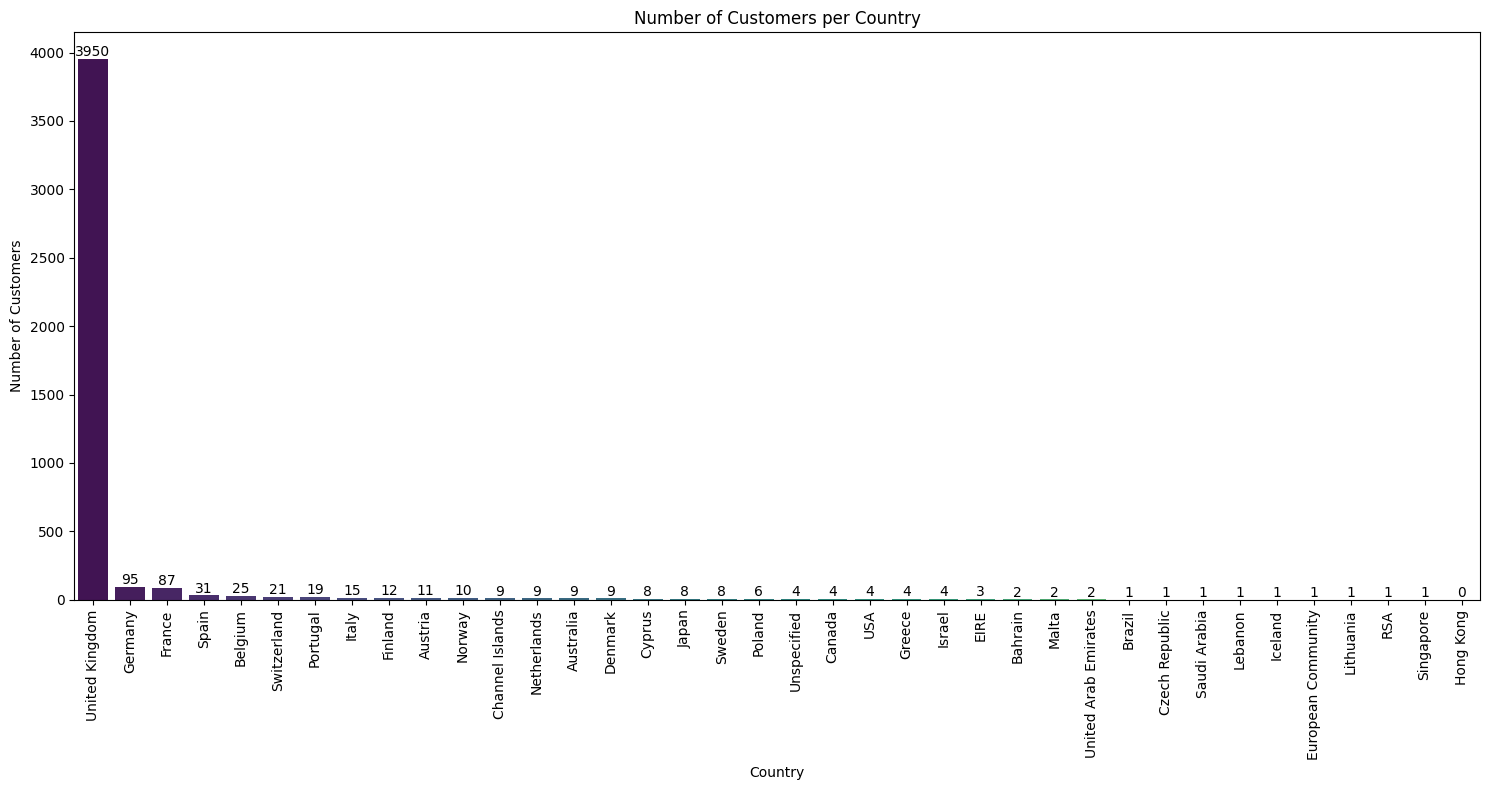

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


data = pd.read_excel("/content/Copy of Retail_Customer_Segmentation2.xlsx")

group_by = data.groupby("Country")
customer_counts = group_by["CustomerID"].nunique().sort_values(ascending=False)
print("Number of customers per country:")
print(customer_counts)

plt.figure(figsize=(15, 8))
ax = sns.barplot(x=customer_counts.index, y=customer_counts.values, palette="viridis", hue=customer_counts.index, legend=False)
plt.xticks(rotation=90)
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.title("Number of Customers per Country")
plt.tight_layout()

    # Add counts on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()



**2. How do customers differ in their purchase behavior?**


Number of customers in each month:
Month
November     1711
October      1425
December     1374
September    1302
May          1079
June         1051
March        1020
July          993
August        980
April         899
February      798
January       783
Name: CustomerID, dtype: int64


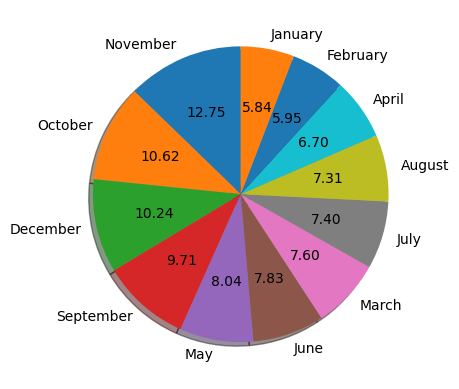

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

group_by2 = data.groupby("Month")
month_value = group_by2["CustomerID"].nunique().sort_values(ascending=False)
print("Number of customers in each month:")
print(month_value)
plt.pie(month_value,labels=month_value.index,shadow=True,autopct="%.2f",startangle=90)
plt.show()

**3. Which customers contribute the most to revenue?**

Number of customers per country:
Country
United Kingdom          3950
Germany                   95
France                    87
Spain                     31
Belgium                   25
Switzerland               21
Portugal                  19
Italy                     15
Finland                   12
Austria                   11
Norway                    10
Channel Islands            9
Netherlands                9
Australia                  9
Denmark                    9
Cyprus                     8
Japan                      8
Sweden                     8
Poland                     6
Unspecified                4
Canada                     4
USA                        4
Greece                     4
Israel                     4
EIRE                       3
Bahrain                    2
Malta                      2
United Arab Emirates       2
Brazil                     1
Czech Republic             1
Saudi Arabia               1
Lebanon                    1
Iceland                    1
Eu

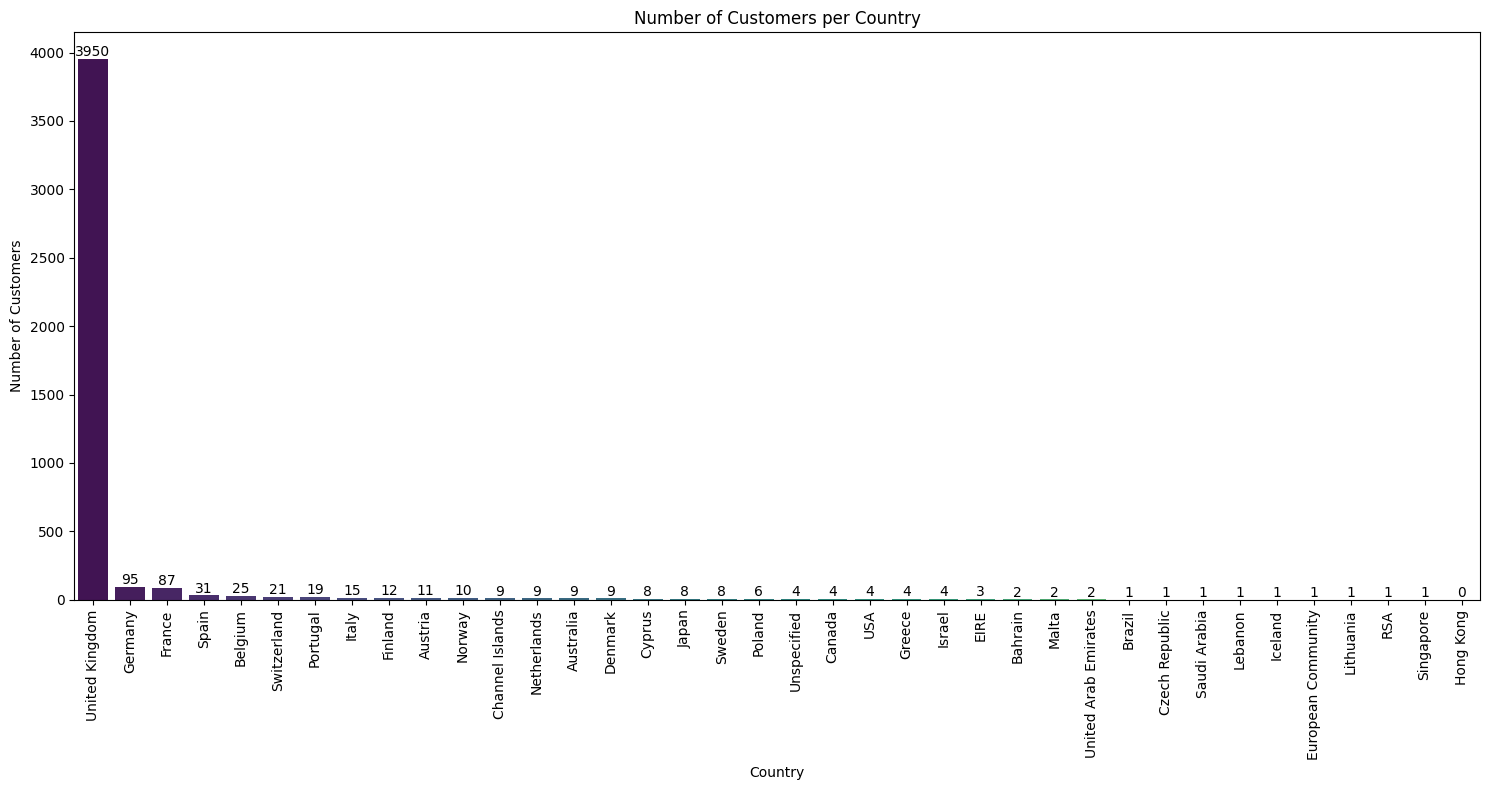

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

group_by = data.groupby("Country")
customer_counts = group_by["CustomerID"].nunique().sort_values(ascending=False)
print("Number of customers per country:")
print(customer_counts)

plt.figure(figsize=(15, 8))
ax = sns.barplot(x=customer_counts.index, y=customer_counts.values, palette="viridis", hue=customer_counts.index, legend=False)
plt.xticks(rotation=90)
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.title("Number of Customers per Country")
plt.tight_layout()

# Add counts on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

**4. Are there patterns based on demographics?**

Number of customers per month:
MonthYear
2010-12     948
2011-01     783
2011-02     798
2011-03    1020
2011-04     899
2011-05    1079
2011-06    1051
2011-07     993
2011-08     980
2011-09    1302
2011-10    1425
2011-11    1711
2011-12     686
Freq: M, Name: CustomerID, dtype: int64


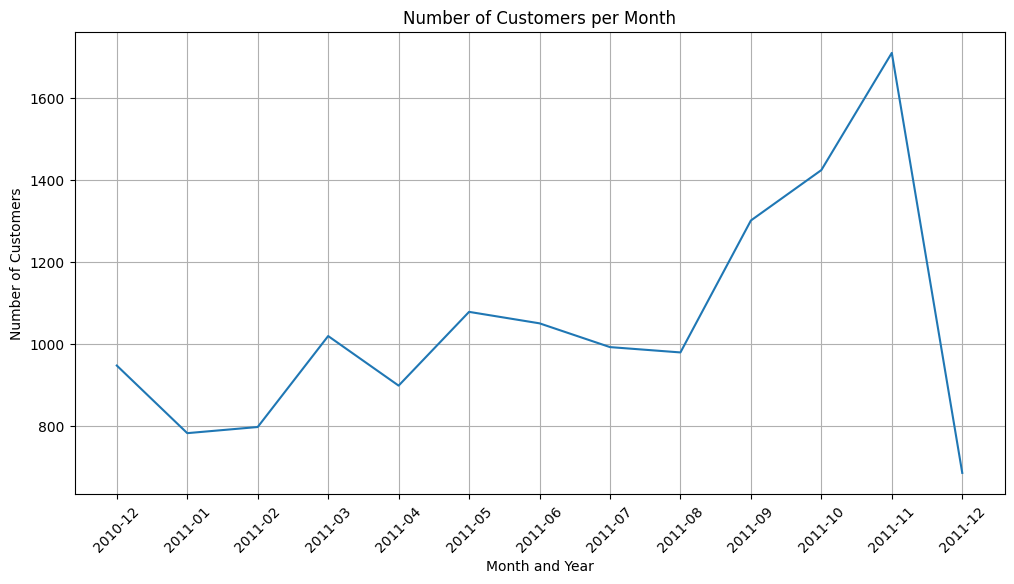

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Convert InvoiceDate to datetime and extract Month-Year
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['MonthYear'] = data['InvoiceDate'].dt.to_period('M')

group_by = data.groupby("MonthYear")
customer_counts = group_by["CustomerID"].nunique() # Keep original order for time series
print("Number of customers per month:")
print(customer_counts)

plt.figure(figsize=(12, 6))
plt.plot(customer_counts.index.astype(str), customer_counts.values) # Convert MonthYear to string for plotting
plt.xlabel("Month and Year")
plt.ylabel("Number of Customers")
plt.title("Number of Customers per Month")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**5. What is the distribution of customer spending?**

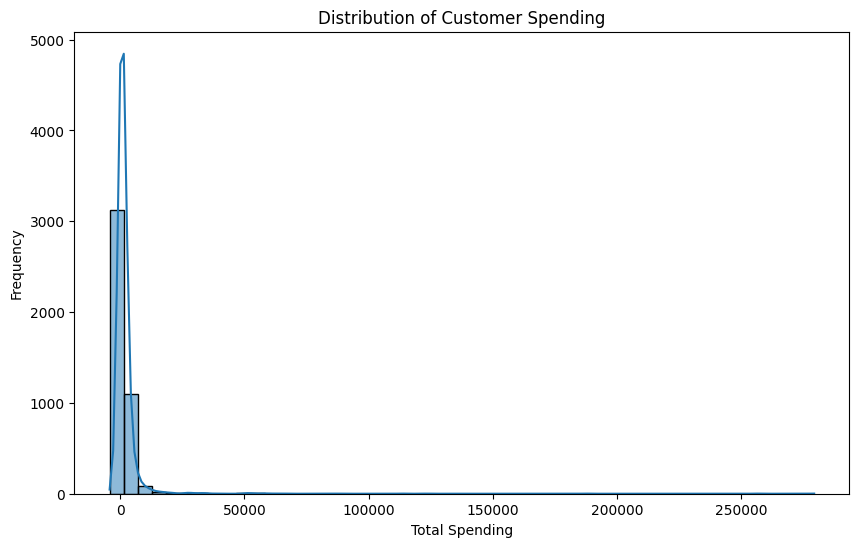

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Calculate TotalSpend for each transaction
data['TotalSpend'] = data['Quantity'] * data['UnitPrice']

# Calculate total spending per customer
customer_total_spend = data.groupby("CustomerID")["TotalSpend"].sum()

# Visualize the distribution of customer spending using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(customer_total_spend, bins=50, kde=True) # Using histplot for histogram
plt.xlabel("Total Spending")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Spending")
plt.show()

**6. How can we segment customers for better targeting?**

Top 10 Top-Spending Customers:


,TotalSpend
CustomerID,
14646.0,279489.02
18102.0,256438.49
17450.0,187482.17
14911.0,132572.62
12415.0,123725.45
14156.0,113384.14
17511.0,88125.38
16684.0,65892.08
13694.0,62653.10



Bottom 20 Least-Spending Customers:


,TotalSpend
CustomerID,
18256.0,-50.10
13672.0,-71.46
15638.0,-94.00
16546.0,-95.93
13829.0,-102.00
13958.0,-102.45
17065.0,-112.35
15728.0,-134.80
17548.0,-141.48


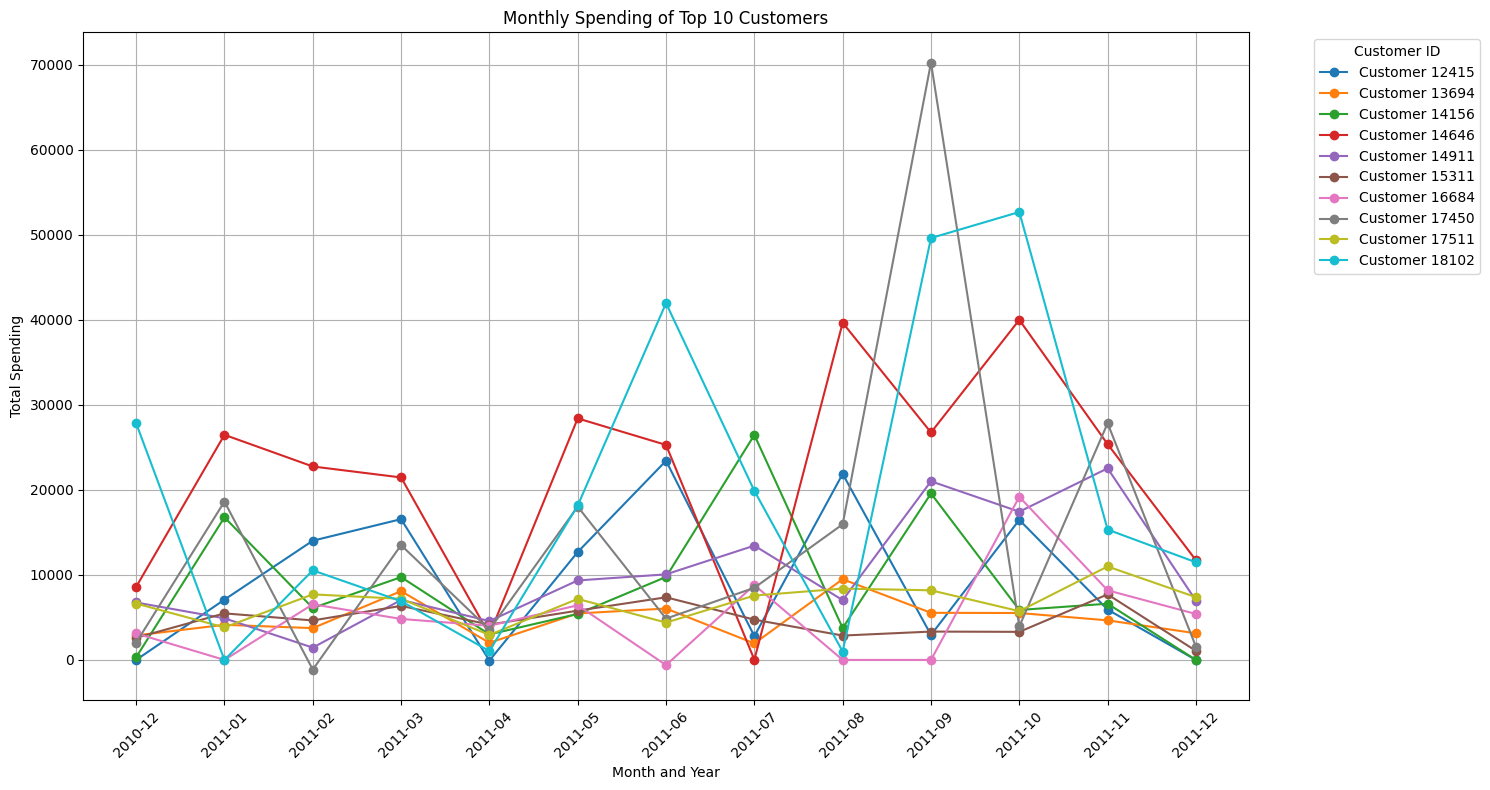

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate TotalSpend for each transaction 

data['TotalSpend'] = data['Quantity'] * data['UnitPrice']

# Calculate total spending per customer and get top 10 customer IDs
customer_total_spend = data.groupby("CustomerID")["TotalSpend"].sum().sort_values(ascending=False)
top_10_customers = customer_total_spend.head(10).index.tolist()

# Display the top 10 top-spending customers
print("Top 10 Top-Spending Customers:")
display(customer_total_spend.head(10))

# Identify and display the bottom 20 least-spending customers
print("\nBottom 20 Least-Spending Customers:")
display(customer_total_spend.tail(20))

# Filter data for top 10 customers
top_10_data = data[data['CustomerID'].isin(top_10_customers)].copy()

# Ensure InvoiceDate is in datetime format and extract MonthYear
top_10_data['InvoiceDate'] = pd.to_datetime(top_10_data['InvoiceDate'])
top_10_data['MonthYear'] = top_10_data['InvoiceDate'].dt.to_period('M')

# Calculate monthly spending for each of the top 10 customers
monthly_spending_top_10 = top_10_data.groupby(['CustomerID', 'MonthYear'])['TotalSpend'].sum().unstack(fill_value=0)

# Plot monthly spending for each top customer
plt.figure(figsize=(15, 8))
for customer_id in monthly_spending_top_10.index:
    # Convert MonthYear index to string for plotting
    months_str = monthly_spending_top_10.columns.astype(str)
    plt.plot(months_str, monthly_spending_top_10.loc[customer_id], marker='o', linestyle='-', label=f'Customer {int(customer_id)}')

plt.xlabel("Month and Year")
plt.ylabel("Total Spending")
plt.title("Monthly Spending of Top 10 Customers")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Customer ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**7.Month with Highest Spending for Each Top 10 Customer:**

Month with Highest Spending for Each Top 10 Customer:


,Highest Spending Month,Highest Spending Value
CustomerID,,
12415.0,2011-06,23426.81
13694.0,2011-08,9493.19
14156.0,2011-07,26464.99
14646.0,2011-10,39995.95
14911.0,2011-11,22536.21
15311.0,2011-11,7707.52
16684.0,2011-10,19180.90
17450.0,2011-09,70246.50
17511.0,2011-11,10991.36


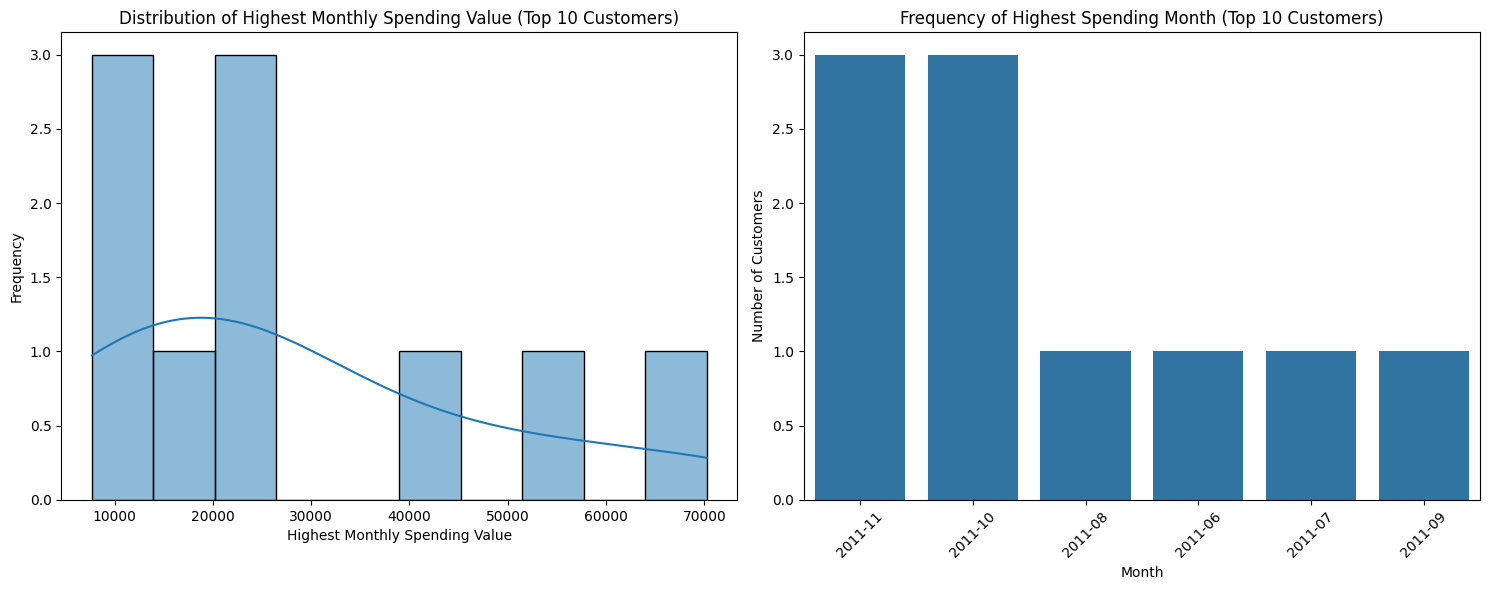

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the data

data = pd.read_excel("/content/Copy of Retail_Customer_Segmentation2.xlsx")
    # Calculate TotalSpend for each transaction 
if 'TotalSpend' not in data.columns:
        data['TotalSpend'] = data['Quantity'] * data['UnitPrice']

    # Calculate total spending per customer and get top 10 customer IDs
customer_total_spend = data.groupby("CustomerID")["TotalSpend"].sum().sort_values(ascending=False)
top_10_customers = customer_total_spend.head(10).index.tolist()
    # Filter data for top 10 customers
top_10_data = data[data['CustomerID'].isin(top_10_customers)].copy()

    # Ensure InvoiceDate is in datetime format and extract MonthYear
top_10_data['InvoiceDate'] = pd.to_datetime(top_10_data['InvoiceDate'])
top_10_data['MonthYear'] = top_10_data['InvoiceDate'].dt.to_period('M')

    # Calculate monthly spending for each of the top 10 customers
monthly_spending_top_10 = top_10_data.groupby(['CustomerID', 'MonthYear'])['TotalSpend'].sum().unstack(fill_value=0)

    # Identify the month with the highest spending for each of the top 10 customers
highest_spending_month = monthly_spending_top_10.idxmax(axis=1)
highest_spending_value = monthly_spending_top_10.max(axis=1)

    # Create a DataFrame to display the results
highest_spending_summary = pd.DataFrame({
        'Highest Spending Month': highest_spending_month,
        'Highest Spending Value': highest_spending_value
    })

print("Month with Highest Spending for Each Top 10 Customer:")
display(highest_spending_summary)

    # Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Histogram of Highest Spending Value
sns.histplot(highest_spending_summary['Highest Spending Value'], bins=10, kde=True, ax=axes[0])
axes[0].set_xlabel("Highest Monthly Spending Value")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Highest Monthly Spending Value (Top 10 Customers)")

    # Plot 2: Count plot of Highest Spending Month
sns.countplot(x=highest_spending_summary['Highest Spending Month'], order=highest_spending_summary['Highest Spending Month'].value_counts().index, ax=axes[1])
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of Customers")
axes[1].set_title("Frequency of Highest Spending Month (Top 10 Customers)")
axes[1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

**8.How concentrated is customer spending, and what percentage of total revenue is generated by the top-spending customers?**

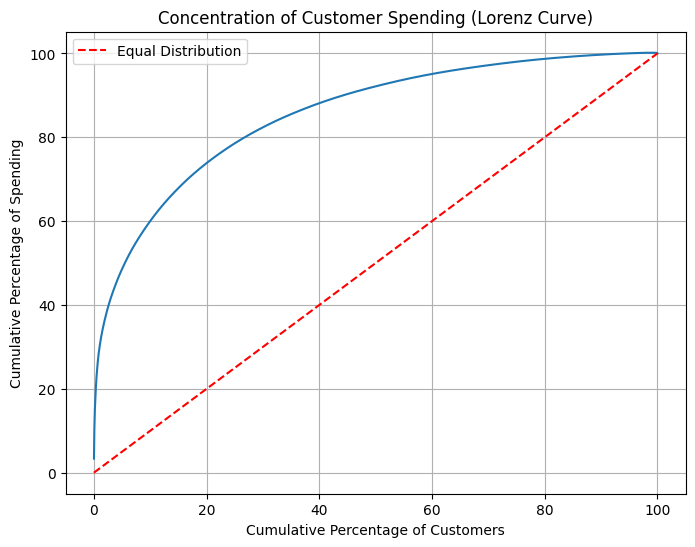

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate TotalSpend for each transaction
data['TotalSpend'] = data['Quantity'] * data['UnitPrice']

# Calculate total spending per customer
customer_total_spend = data.groupby("CustomerID")["TotalSpend"].sum().sort_values(ascending=False)

# Calculate cumulative spending and cumulative percentage of customers
customer_total_spend_cum = customer_total_spend.cumsum()
customer_percentage_cum = (customer_total_spend_cum / customer_total_spend.sum()) * 100
customer_index_percentage = (pd.Series(range(1, len(customer_total_spend) + 1)) / len(customer_total_spend)) * 100

# Create the Lorenz curve plot
plt.figure(figsize=(8, 6))
plt.plot(customer_index_percentage, customer_percentage_cum)
plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Equal Distribution') # Line of equal distribution
plt.xlabel("Cumulative Percentage of Customers")
plt.ylabel("Cumulative Percentage of Spending")
plt.title("Concentration of Customer Spending (Lorenz Curve)")
plt.grid(True)
plt.legend()
plt.show()

**9. How does purchase frequency vary across customers?**

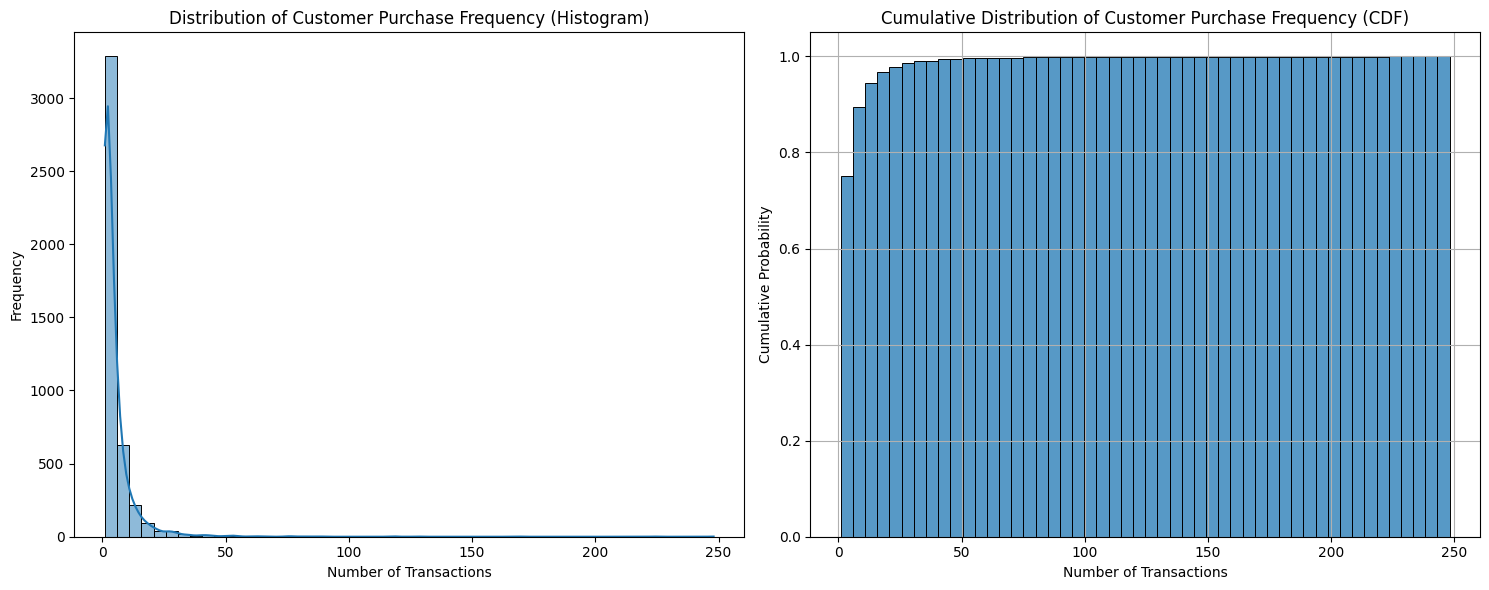

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Calculate the number of unique invoices per customer
customer_frequency = data.groupby("CustomerID")["InvoiceNo"].nunique()

# Create subplots for histogram and CDF plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram of purchase frequency
sns.histplot(customer_frequency, bins=50, kde=True, ax=axes[0])
axes[0].set_xlabel("Number of Transactions")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Customer Purchase Frequency (Histogram)")

# CDF plot of purchase frequency
sns.histplot(customer_frequency, bins=50, cumulative=True, kde=False, stat="density", ax=axes[1])
axes[1].set_xlabel("Number of Transactions")
axes[1].set_ylabel("Cumulative Probability")
axes[1].set_title("Cumulative Distribution of Customer Purchase Frequency (CDF)")
axes[1].grid(True)


plt.tight_layout()
plt.show()

**10.How does purchase frequency vary across months, and are there any seasonal trends or spikes in the number of transactions?**

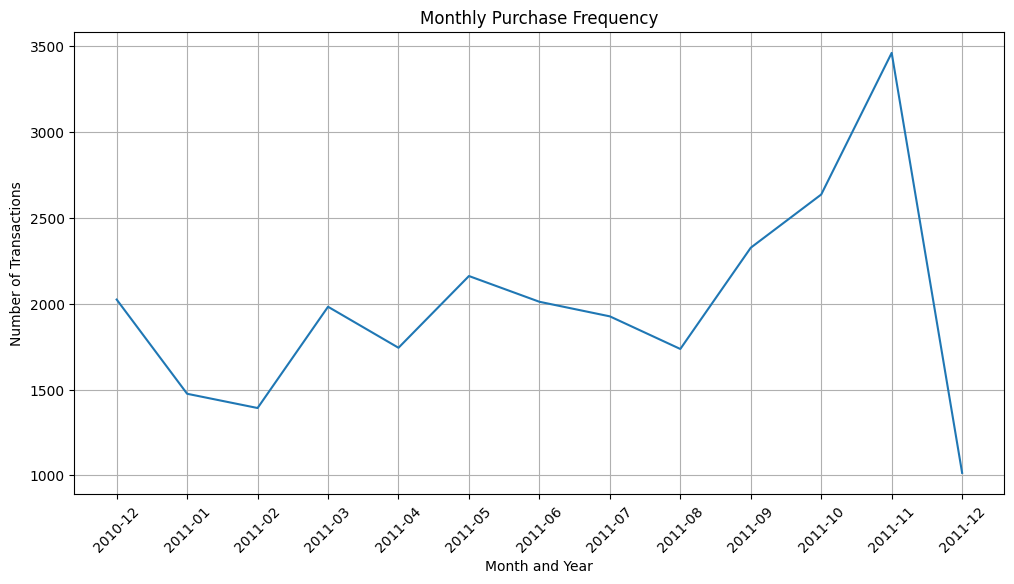

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure InvoiceDate is in datetime format and extract MonthYear
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['MonthYear'] = data['InvoiceDate'].dt.to_period('M')

# Calculate the number of unique invoices per month
monthly_frequency = data.groupby('MonthYear')['InvoiceNo'].nunique()

# Visualize the monthly purchase frequency
plt.figure(figsize=(12, 6))
plt.plot(monthly_frequency.index.astype(str), monthly_frequency.values)
plt.xlabel("Month and Year")
plt.ylabel("Number of Transactions")
plt.title("Monthly Purchase Frequency")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**11. What products or categories do different segments prefer?**

/tmp/ipython-input-3207158220.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products_top_10.index, y=top_products_top_10.values, palette='viridis')


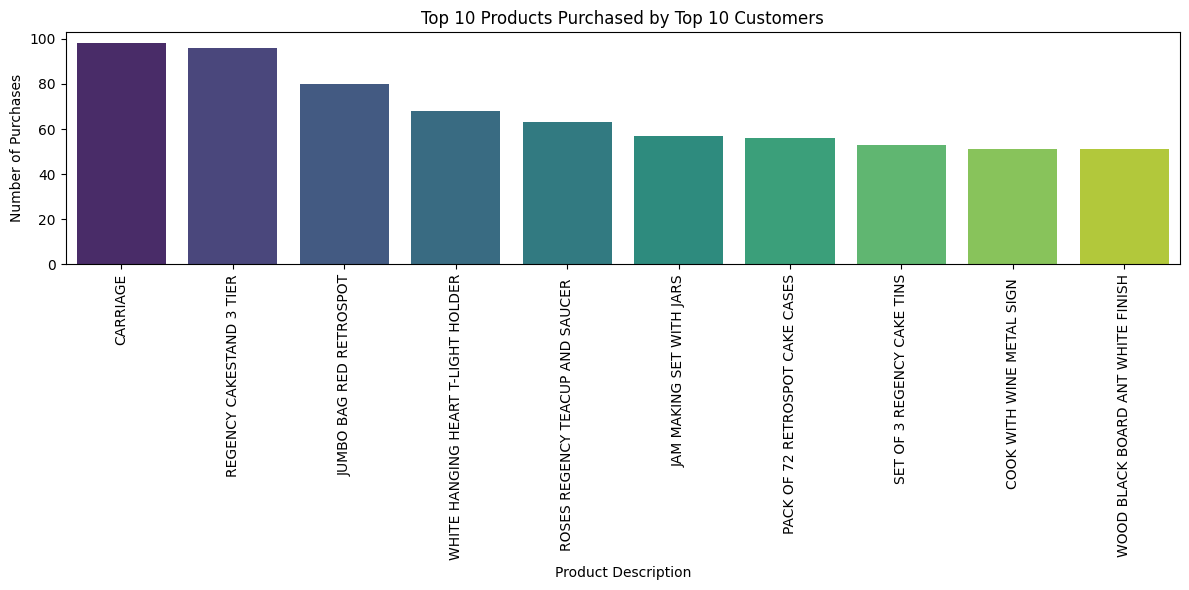

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data = pd.read_excel("/content/Copy of Retail_Customer_Segmentation2.xlsx")
 # Calculate TotalSpend for each transaction (if not already done)
data['TotalSpend'] = data['Quantity'] * data['UnitPrice']

# Calculate total spending per customer and get top 10 customer IDs
 customer_total_spend = data.groupby("CustomerID")["TotalSpend"].sum().sort_values(ascending=False)
top_10_customers = customer_total_spend.head(10).index.tolist()

# Filter data for top 10 customers
top_10_data = data[data['CustomerID'].isin(top_10_customers)].copy()

    # Analyze product popularity among top 10 customers
top_products_top_10 = top_10_data['Description'].value_counts().head(10)

    # Visualize the top products purchased by top 10 customers
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products_top_10.index, y=top_products_top_10.values, palette='viridis')
plt.xlabel("Product Description")
plt.ylabel("Number of Purchases")
plt.title("Top 10 Products Purchased by Top 10 Customers")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**12. What is the average customer lifetime value (CLV)?**

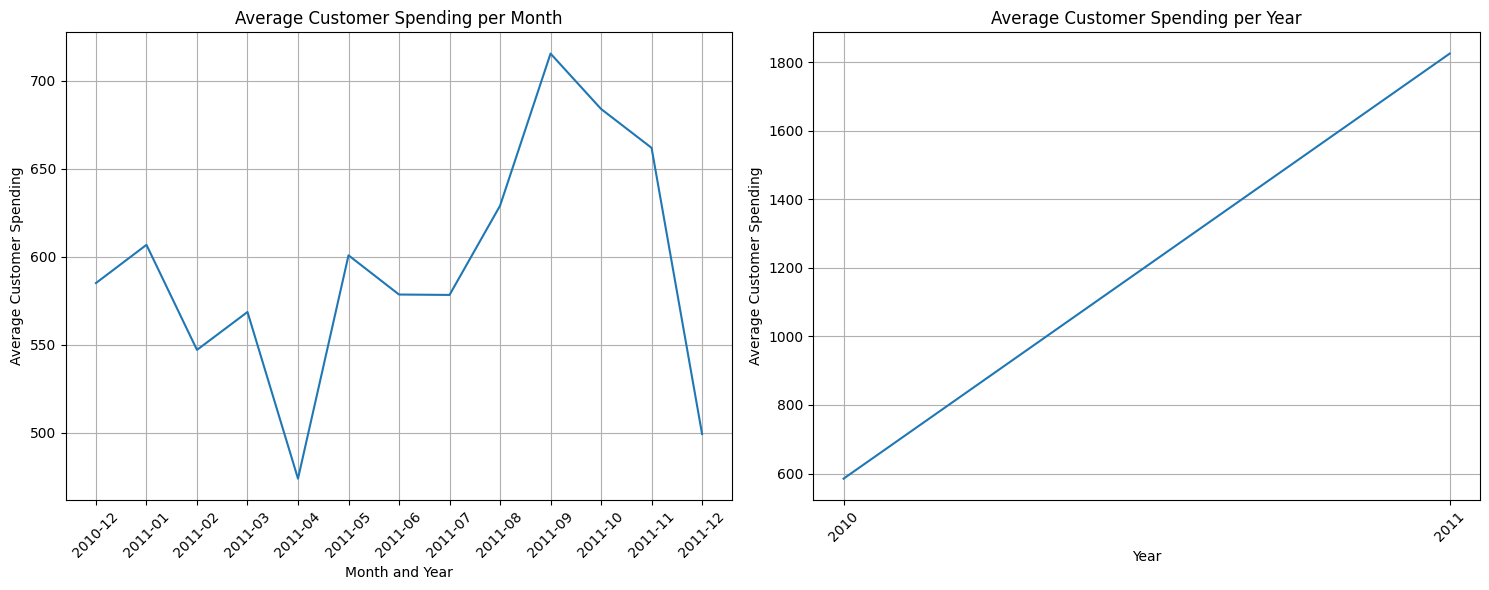

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the data
data = pd.read_excel("/content/Copy of Retail_Customer_Segmentation2.xlsx")



    # Ensure InvoiceDate is in datetime format and extract Month and Year
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['MonthYear'] = data['InvoiceDate'].dt.to_period('M')
data['Year'] = data['InvoiceDate'].dt.to_period('Y')
    # Calculate TotalSpend for each transaction (if not already done)
if 'TotalSpend' not in data.columns:
        data['TotalSpend'] = data['Quantity'] * data['UnitPrice']

    # Calculate average customer spending per month
monthly_avg_spend = data.groupby(['CustomerID', 'MonthYear'])['TotalSpend'].sum().groupby('MonthYear').mean()

    # Calculate average customer spending per year
yearly_avg_spend = data.groupby(['CustomerID', 'Year'])['TotalSpend'].sum().groupby('Year').mean()

    # Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot average customer spending per month
axes[0].plot(monthly_avg_spend.index.astype(str), monthly_avg_spend.values)
axes[0].set_xlabel("Month and Year")
axes[0].set_ylabel("Average Customer Spending")
axes[0].set_title("Average Customer Spending per Month")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)

    # Plot average customer spending per year
axes[1].plot(yearly_avg_spend.index.astype(str), yearly_avg_spend.values)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average Customer Spending")
axes[1].set_title("Average Customer Spending per Year")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True)

plt.tight_layout()
plt.show()


**13. Are there seasonal or time-based trends?**

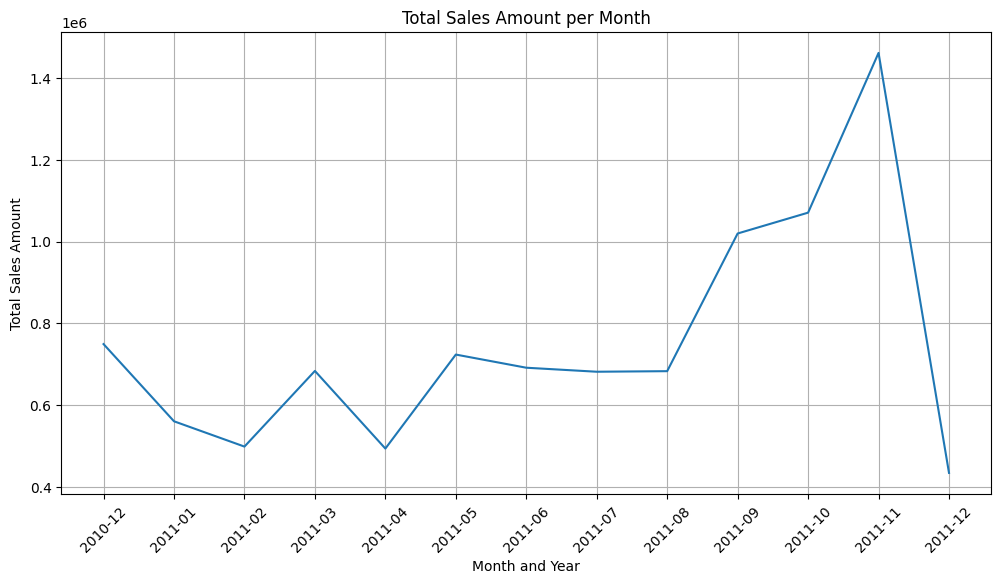

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure InvoiceDate is in datetime format and extract MonthYear
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['MonthYear'] = data['InvoiceDate'].dt.to_period('M')

# Calculate TotalSpend for each transaction (if not already done)
if 'TotalSpend' not in data.columns:
    data['TotalSpend'] = data['Quantity'] * data['UnitPrice']

# Calculate total sales amount per month
monthly_sales = data.groupby('MonthYear')['TotalSpend'].sum()

# Visualize the monthly sales amount
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)
plt.xlabel("Month and Year")
plt.ylabel("Total Sales Amount")
plt.title("Total Sales Amount per Month")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**14.How does the number of sales vary throughout the day, and what are the peak hours for transactions?**

/tmp/ipython-input-1067957999.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_sales_count.index, y=hourly_sales_count.values, palette='viridis')


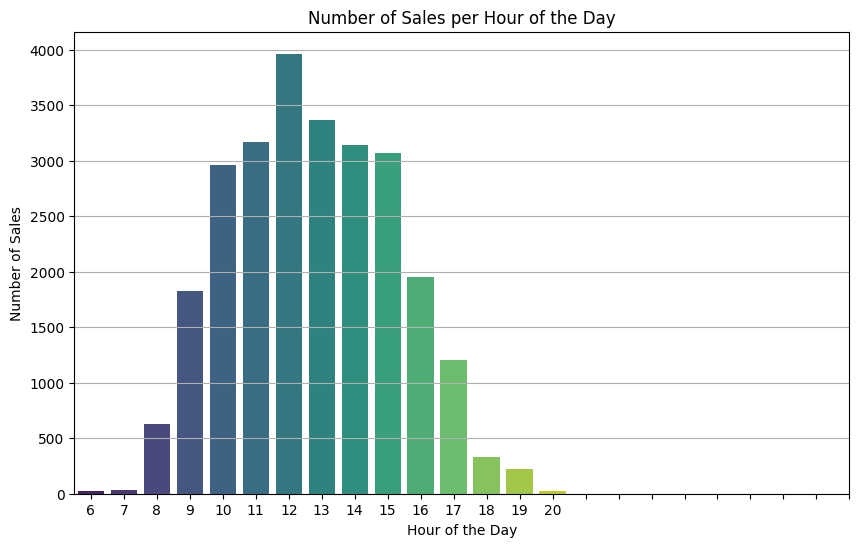

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ensure InvoiceDate is in datetime format
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Extract the hour from the InvoiceDate
data['InvoiceHour'] = data['InvoiceDate'].dt.hour

# Calculate the number of unique invoices per hour
hourly_sales_count = data.groupby('InvoiceHour')['InvoiceNo'].nunique()

# Visualize the number of sales per hour
plt.figure(figsize=(10, 6))
sns.barplot(x=hourly_sales_count.index, y=hourly_sales_count.values, palette='viridis')
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Sales")
plt.title("Number of Sales per Hour of the Day")
plt.xticks(range(24)) # Ensure all hours from 0 to 23 are shown on x-axis
plt.grid(axis='y')
plt.show()

**15. What is the churn rate of customers?**

/tmp/ipython-input-697238030.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frequency_counts.index, y=frequency_counts.values, palette="viridis")


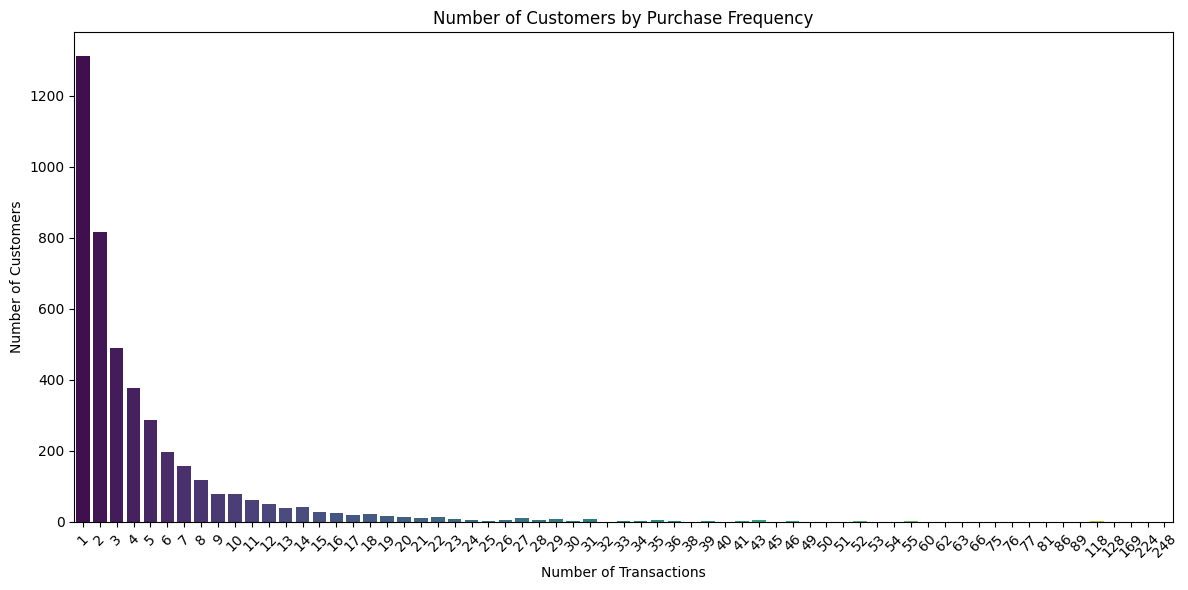

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Calculate the number of unique invoices per customer
customer_frequency = data.groupby("CustomerID")["InvoiceNo"].nunique()

# Count the number of customers for each frequency level
frequency_counts = customer_frequency.value_counts().sort_index()

# Visualize the number of customers for each purchase frequency
plt.figure(figsize=(12, 6))
sns.barplot(x=frequency_counts.index, y=frequency_counts.values, palette="viridis")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")
plt.title("Number of Customers by Purchase Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**16. How do high-value customers differ from low-value ones?**

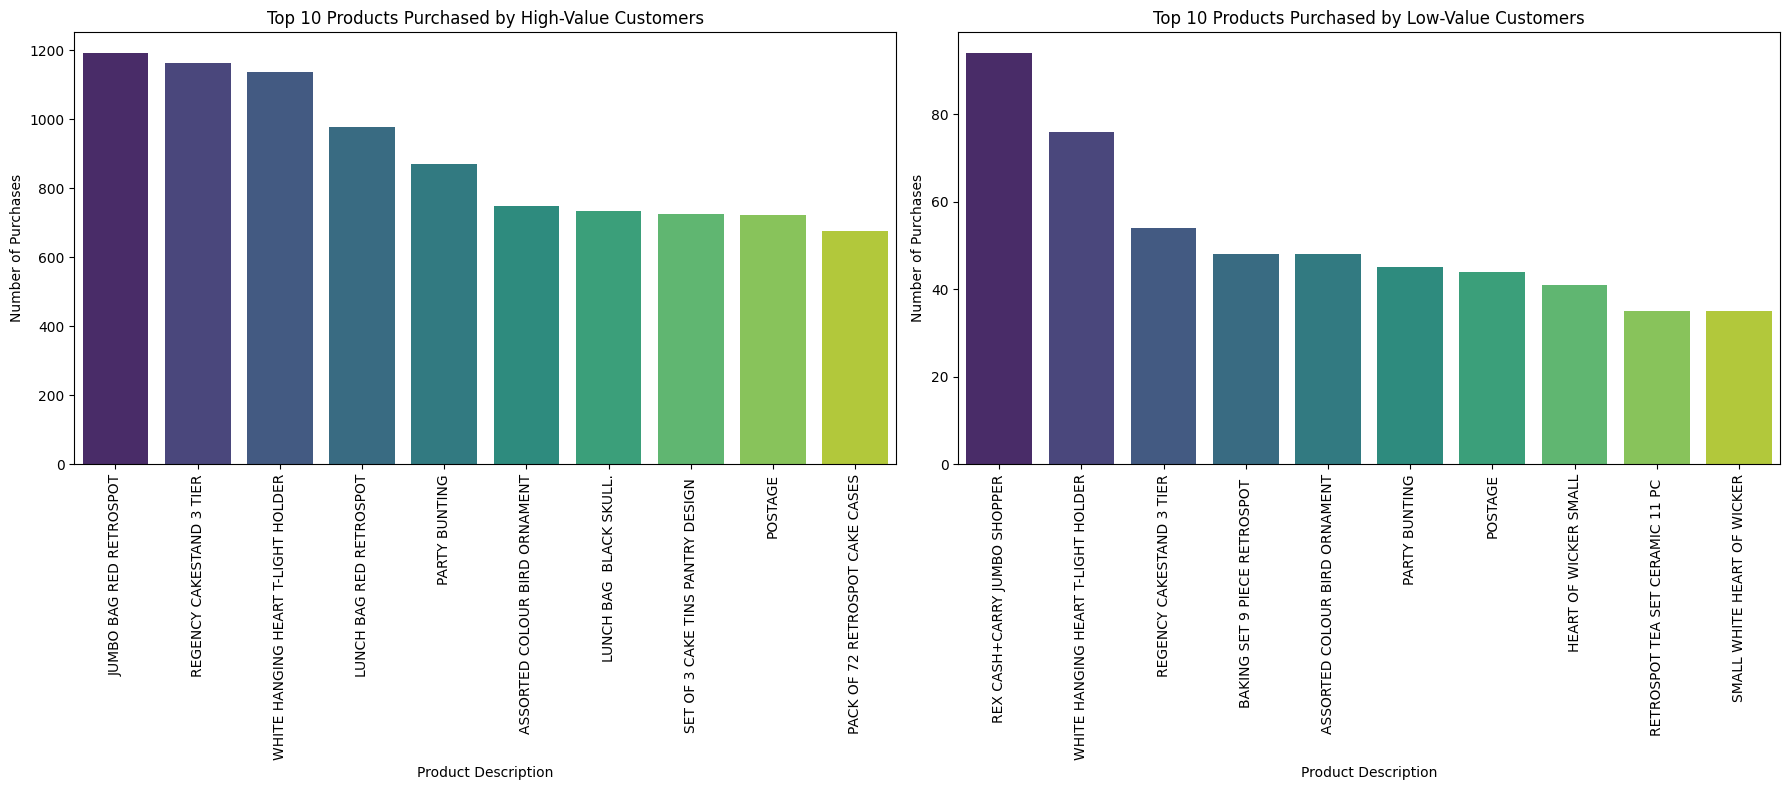

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Calculate TotalSpend for each transaction 

data['TotalSpend'] = data['Quantity'] * data['UnitPrice']

# Calculate total spending per customer
customer_total_spend = data.groupby("CustomerID")["TotalSpend"].sum()

# Define high-value and low-value customers based on spending quartiles (excluding negative spending for low-value)
filtered_spend = customer_total_spend[customer_total_spend >= 0] # Exclude negative spending for low-value analysis

high_value_threshold = filtered_spend.quantile(0.8)
low_value_threshold = filtered_spend.quantile(0.2)

high_value_customers = filtered_spend[filtered_spend >= high_value_threshold].index.tolist()
low_value_customers = filtered_spend[filtered_spend <= low_value_threshold].index.tolist()

# Filter data for high-value and low-value customers
high_value_data = data[data['CustomerID'].isin(high_value_customers)].copy()
low_value_data = data[data['CustomerID'].isin(low_value_customers)].copy()

# Analyze product popularity for high-value customers
top_products_high_value = high_value_data['Description'].value_counts().head(10)

# Analyze product popularity for low-value customers
top_products_low_value = low_value_data['Description'].value_counts().head(10)

# Create subplots to visualize top products for each segment
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot for high-value customers
sns.barplot(x=top_products_high_value.index, y=top_products_high_value.values, palette='viridis', ax=axes[0], hue=top_products_high_value.index, legend=False)
axes[0].set_xlabel("Product Description")
axes[0].set_ylabel("Number of Purchases")
axes[0].set_title("Top 10 Products Purchased by High-Value Customers")
axes[0].tick_params(axis='x', rotation=90)

# Plot for low-value customers
sns.barplot(x=top_products_low_value.index, y=top_products_low_value.values, palette='viridis', ax=axes[1], hue=top_products_low_value.index, legend=False)
axes[1].set_xlabel("Product Description")
axes[1].set_ylabel("Number of Purchases")
axes[1].set_title("Top 10 Products Purchased by Low-Value Customers")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

**17. What marketing strategy can be derived from segmentation?**

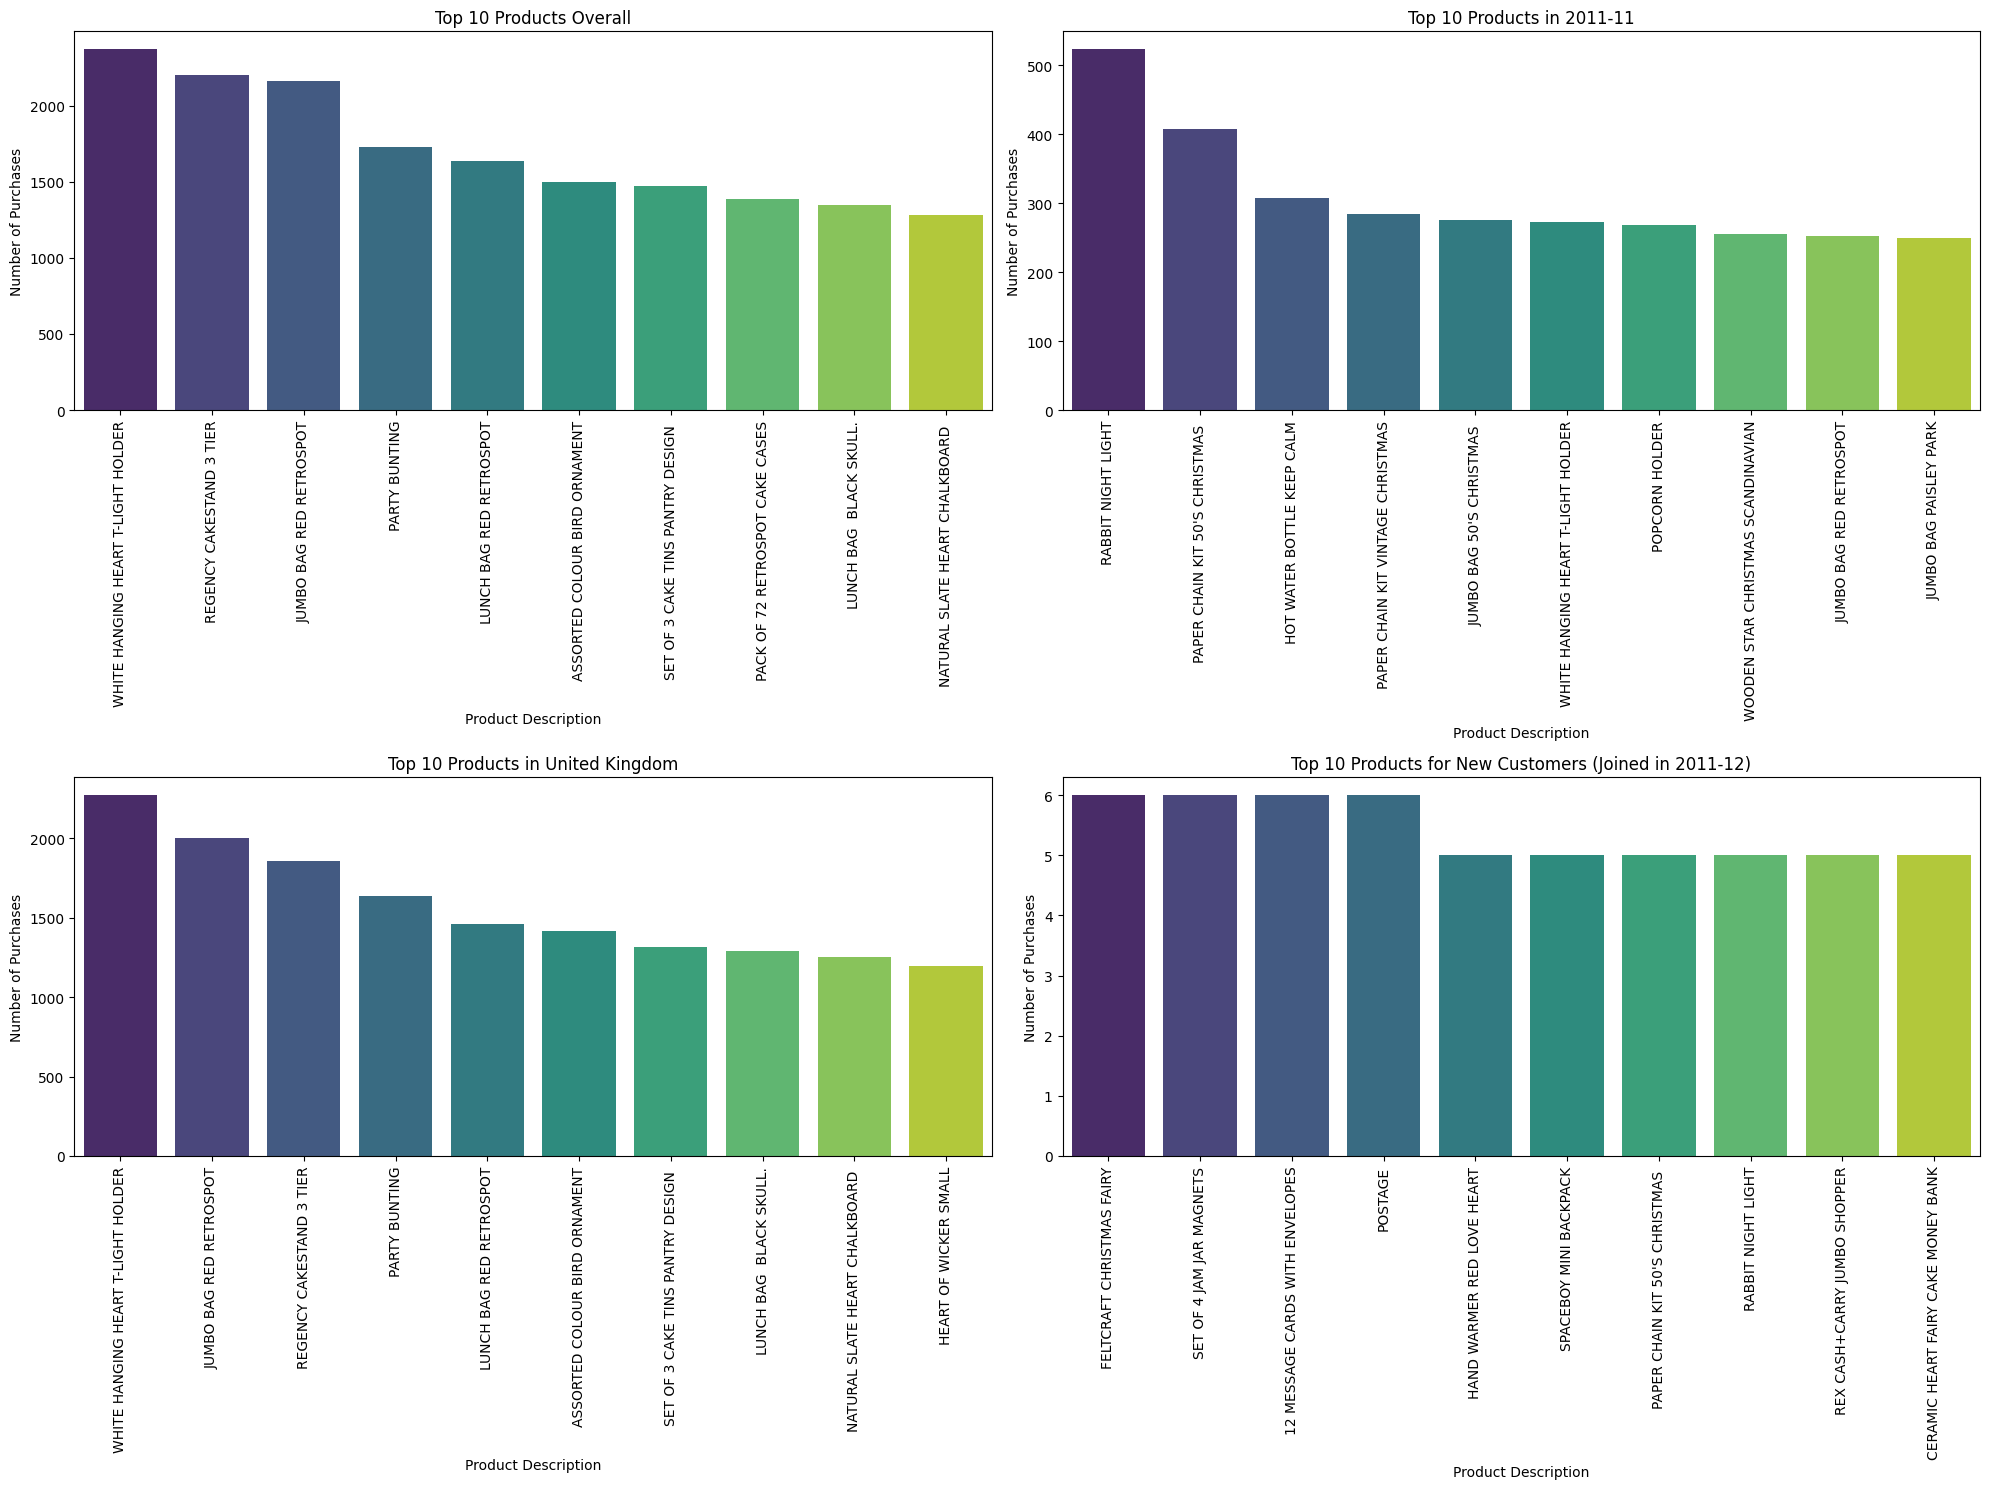

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ensure InvoiceDate is in datetime format and extract MonthYear
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['MonthYear'] = data['InvoiceDate'].dt.to_period('M')

# Calculate TotalSpend for each transaction (if not already done)

data['TotalSpend'] = data['Quantity'] * data['UnitPrice']

# --- Analyze Top Products Overall ---
top_products_overall = data['Description'].value_counts().head(10)

# --- Analyze Top Products in Peak Sales Month (November 2011 based on previous analysis) ---
peak_month = '2011-11' # Assuming November 2011 as peak based on previous plot
peak_month_data = data[data['MonthYear'].astype(str) == peak_month]
top_products_peak_month = peak_month_data['Description'].value_counts().head(10)

# --- Analyze Top Products in Top Country (United Kingdom based on previous analysis) ---
top_country = 'United Kingdom' # Assuming United Kingdom as top country based on previous plot
top_country_data = data[data['Country'] == top_country]
top_products_top_country = top_country_data['Description'].value_counts().head(10)

# --- Analyze Top Products for New Customers (Customers who made their first purchase in the last month) ---
# Find the date of the first purchase for each customer
first_purchase_date = data.groupby('CustomerID')['InvoiceDate'].min()
# Identify customers whose first purchase was in the last month of the dataset
last_month = data['MonthYear'].max()
new_customers_this_month = first_purchase_date[first_purchase_date.dt.to_period('M') == last_month].index.tolist()
# Filter data for these new customers
new_customer_data = data[data['CustomerID'].isin(new_customers_this_month)]
top_products_new_customers = new_customer_data['Description'].value_counts().head(10)


# --- Create Subplots ---
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

# Plot 1: Top Products Overall
sns.barplot(x=top_products_overall.index, y=top_products_overall.values, palette='viridis', ax=axes[0], hue=top_products_overall.index, legend=False)
axes[0].set_xlabel("Product Description")
axes[0].set_ylabel("Number of Purchases")
axes[0].set_title("Top 10 Products Overall")
axes[0].tick_params(axis='x', rotation=90)

# Plot 2: Top Products in Peak Sales Month
sns.barplot(x=top_products_peak_month.index, y=top_products_peak_month.values, palette='viridis', ax=axes[1], hue=top_products_peak_month.index, legend=False)
axes[1].set_xlabel("Product Description")
axes[1].set_ylabel("Number of Purchases")
axes[1].set_title(f"Top 10 Products in {peak_month}")
axes[1].tick_params(axis='x', rotation=90)

# Plot 3: Top Products in Top Country
sns.barplot(x=top_products_top_country.index, y=top_products_top_country.values, palette='viridis', ax=axes[2], hue=top_products_top_country.index, legend=False)
axes[2].set_xlabel("Product Description")
axes[2].set_ylabel("Number of Purchases")
axes[2].set_title(f"Top 10 Products in {top_country}")
axes[2].tick_params(axis='x', rotation=90)

# Plot 4: Top Products for New Customers
sns.barplot(x=top_products_new_customers.index, y=top_products_new_customers.values, palette='viridis', ax=axes[3], hue=top_products_new_customers.index, legend=False)
axes[3].set_xlabel("Product Description")
axes[3].set_ylabel("Number of Purchases")
axes[3].set_title(f"Top 10 Products for New Customers (Joined in {last_month.strftime('%Y-%m')})")
axes[3].tick_params(axis='x', rotation=90)


plt.tight_layout()
plt.show()